<h1>Лабораторна робота No1</h1>

<h5>Морфологiя</h5>

Мета: Метою цiєї лабораторної роботи є отримання навичок роботи з морфологi-
чними операцiями над бiнарними зображеннями.

Завантажуємо потрібні бібліотекі

In [184]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Завантажуємо зображення

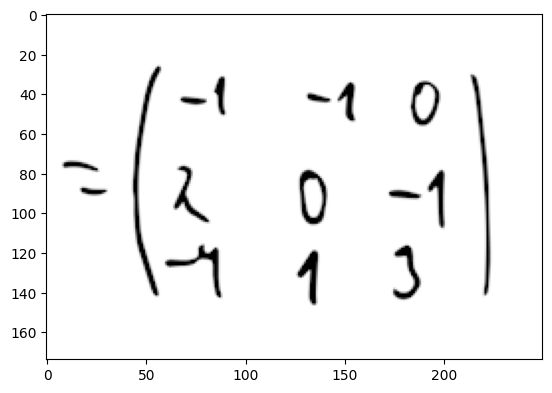

In [185]:
img = cv2.imread("img.png")
img,r,g = cv2.split(img)
plt.imshow(img, cmap="gray")

Робимо глобальну бінарізацію

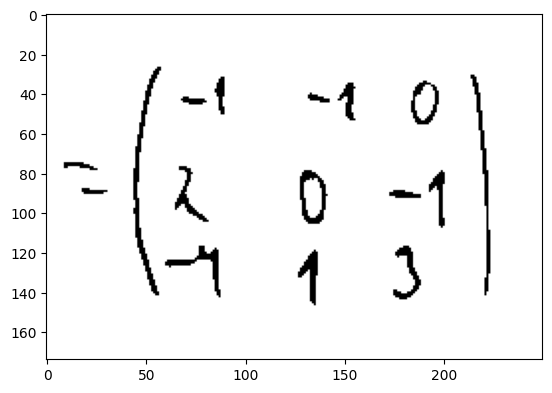

In [186]:
def global_auto_threshold(img, max_iter=100, eps=0.5):
    hist_np = np.zeros(256, dtype=int)#заповнюємо нулями
    uniq, count = np.unique(img, return_counts=True)#виводимо список унікальних значень, та список їх кількості
    hist_np[uniq] = count#в списку нашої гістограми, змінюмо ті значення, які входять до unique, на значення з count
    all_pixel = img.shape[0]*img.shape[1]
    probability_brightness = hist_np/all_pixel
    max_dis = 0
    porog = 0
    for t in range(0,256):
        q1=  0
        q2 = 0
        u1 = 0 
        u2 = 0    
        for j in range(0,t):
            q1 += probability_brightness[j]
        for j in range(t,256):
            q2 += probability_brightness[j]
        for k in range(0,t):
            u1 += k*probability_brightness[k]/q1       
        for k in range(t,256):
            u2 += k*probability_brightness[k]/q2
        final_variable = q1*q2*(u1-u2)**2
        if final_variable > max_dis:
            max_dis = final_variable
            porog = t
    binary_image = np.where(img >= porog, 255, 0)
    return binary_image
img = global_auto_threshold(img)
plt.imshow(img, cmap="grey")

Структурний елемент

In [187]:
cell = np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0]
], dtype=np.uint8)
print(cell)

[[0 1 0]
 [1 1 1]
 [0 1 0]]


Функція що додає край на зображення(буде використовуватися в інших функціях)

In [188]:
def pad_image(img, se):
    pad_y = se.shape[0] // 2
    pad_x = se.shape[1] // 2
    return np.pad(img, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant',constant_values=255)


Функція що виконує ерозію

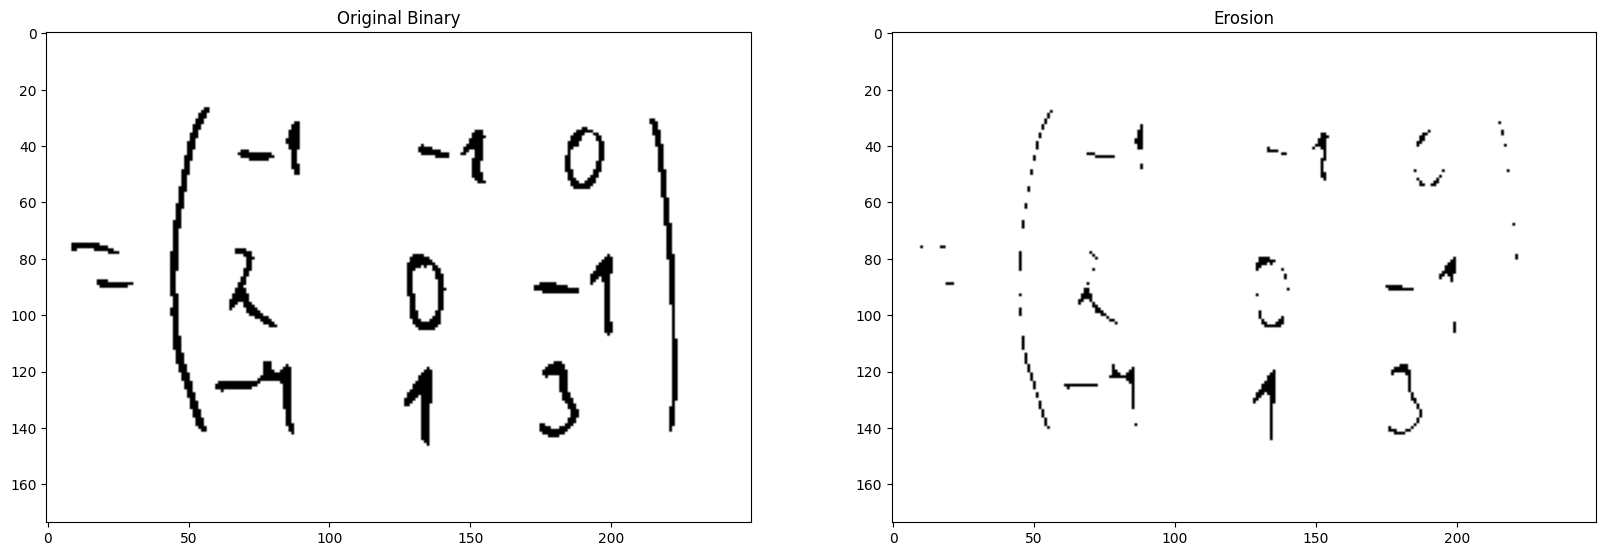

In [189]:
def erosion(img, se):
    padded = pad_image(img, se)
    h, w = img.shape
    se_h, se_w = se.shape
    out = np.zeros_like(img) + 255
    for y in range(h):
        for x in range(w):
            region = padded[y:y+se_h, x:x+se_w]
            if np.all(region[se == 1] == 0):
                out[y, x] = 0
    return out
er = erosion(img,cell)
plt.figure(figsize=(20, 15))
plt.subplot(1,2,1)
plt.title("Original Binary")
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title("Erosion")
plt.imshow(er, cmap="grey")

Функція що виконує нарощування

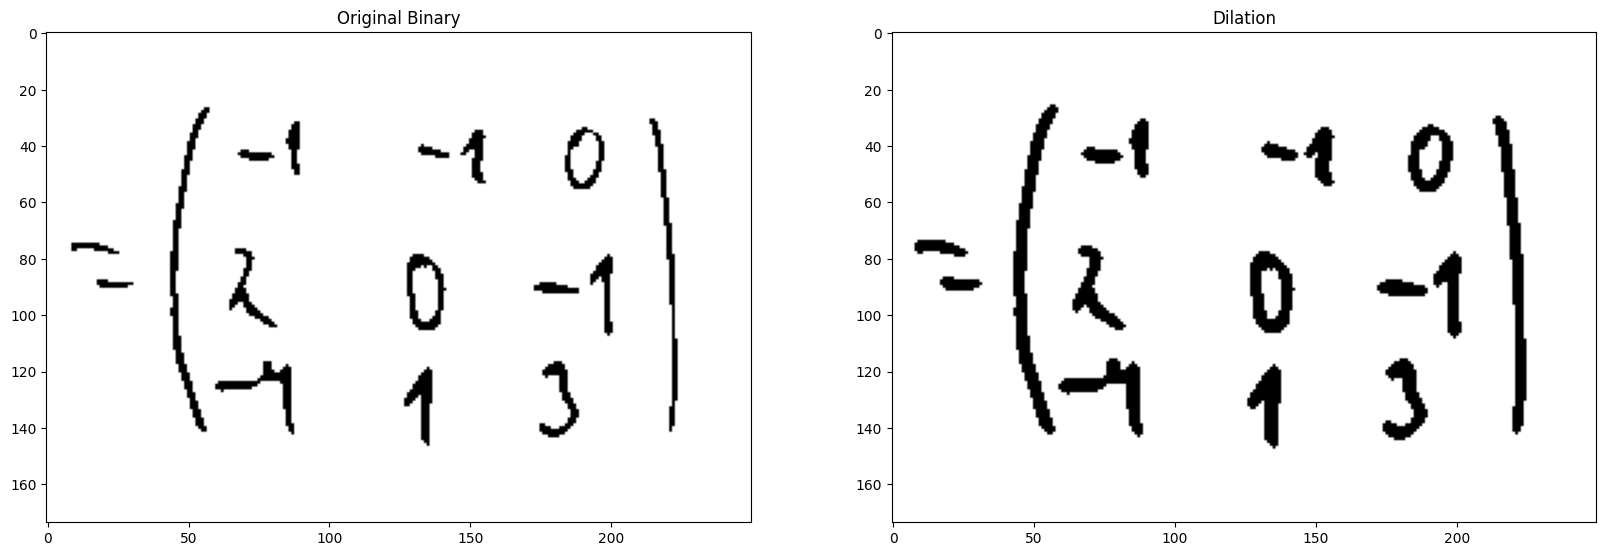

In [190]:
def dilation(img, se):
    """Нарощування (Dilation)"""
    padded = pad_image(img, se)
    h, w = img.shape
    se_h, se_w = se.shape
    out = np.zeros_like(img) + 255

    for y in range(h):
        for x in range(w):
            region = padded[y:y+se_h, x:x+se_w]
            if np.any(region[se == 1] == 0):
                out[y, x] = 0
    return out
dil = dilation(img,cell)
plt.figure(figsize=(20, 15))
plt.subplot(1,2,1)
plt.title("Original Binary")
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title("Dilation")
plt.imshow(dil, cmap="grey")

Функція що виконує розмикання

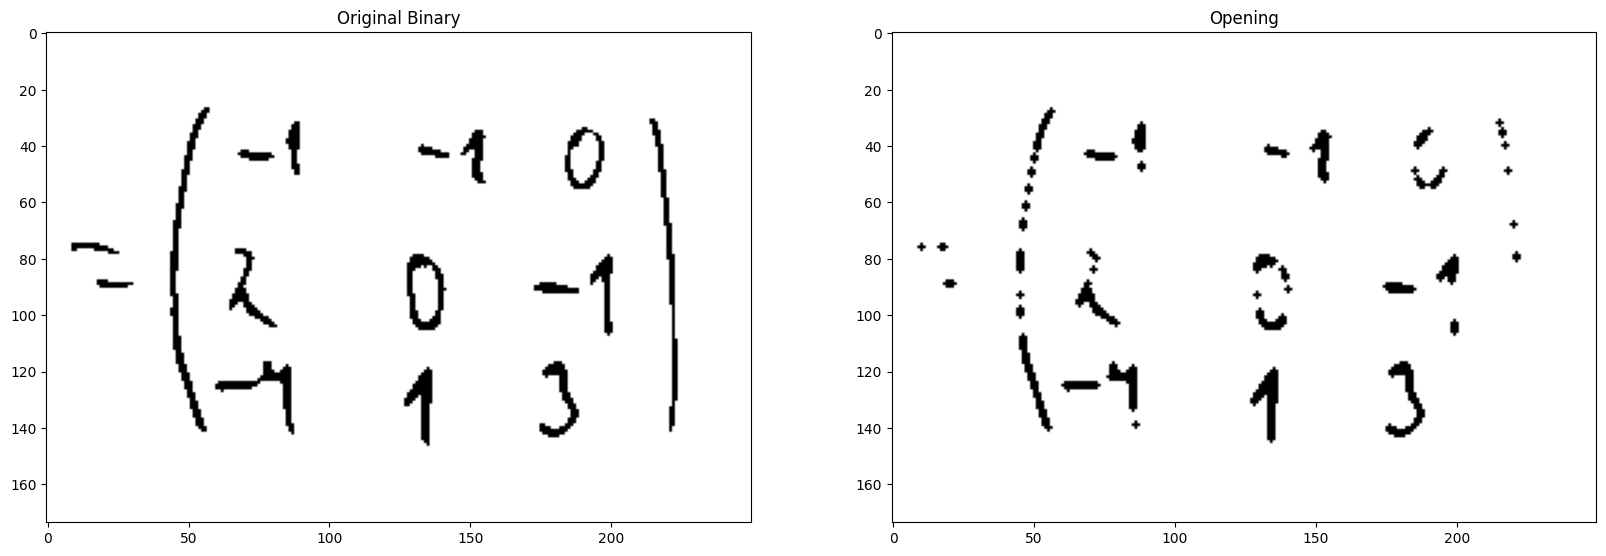

In [191]:
def opening(img, se):
    """Розмикання = Ерозія → Нарощування"""
    return dilation(erosion(img, se), se)

op = opening(img,cell)
plt.figure(figsize=(20, 15))
plt.subplot(1,2,1)
plt.title("Original Binary")
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title("Opening")
plt.imshow(op, cmap="grey")

Функція що виконує замикання

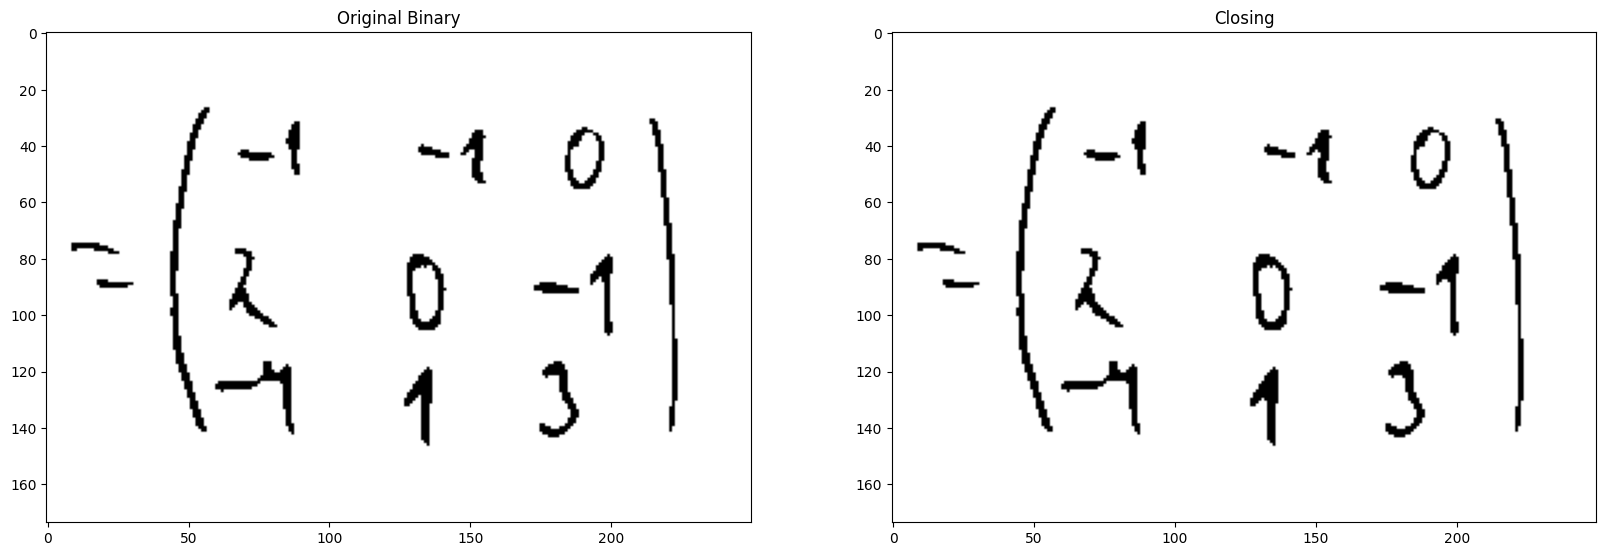

In [192]:
def closing(img, se):
    """Замикання = Нарощування → Ерозія"""
    return erosion(dilation(img, se), se)
clo = closing(img,cell)

plt.figure(figsize=(20, 15))
plt.subplot(1,2,1)
plt.title("Original Binary")
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title("Closing")
plt.imshow(clo, cmap="grey")

Ункція що робить границю у нашого зображення

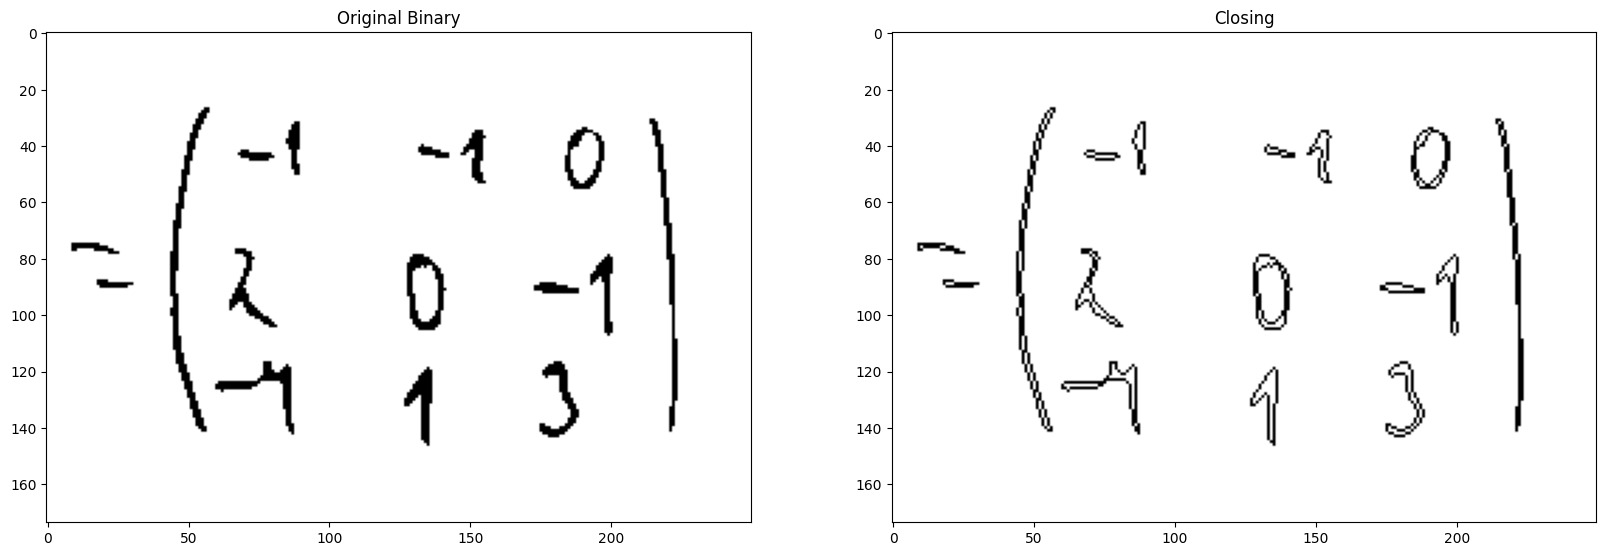

In [193]:
def boundary(img, se):
    return img - erosion(img, se)
bound = boundary(img,cell)

plt.figure(figsize=(20, 15))
plt.subplot(1,2,1)
plt.title("Original Binary")
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title("Closing")
plt.imshow(bound, cmap="grey")

Повний вивід наших зображень, після морфологічних операції

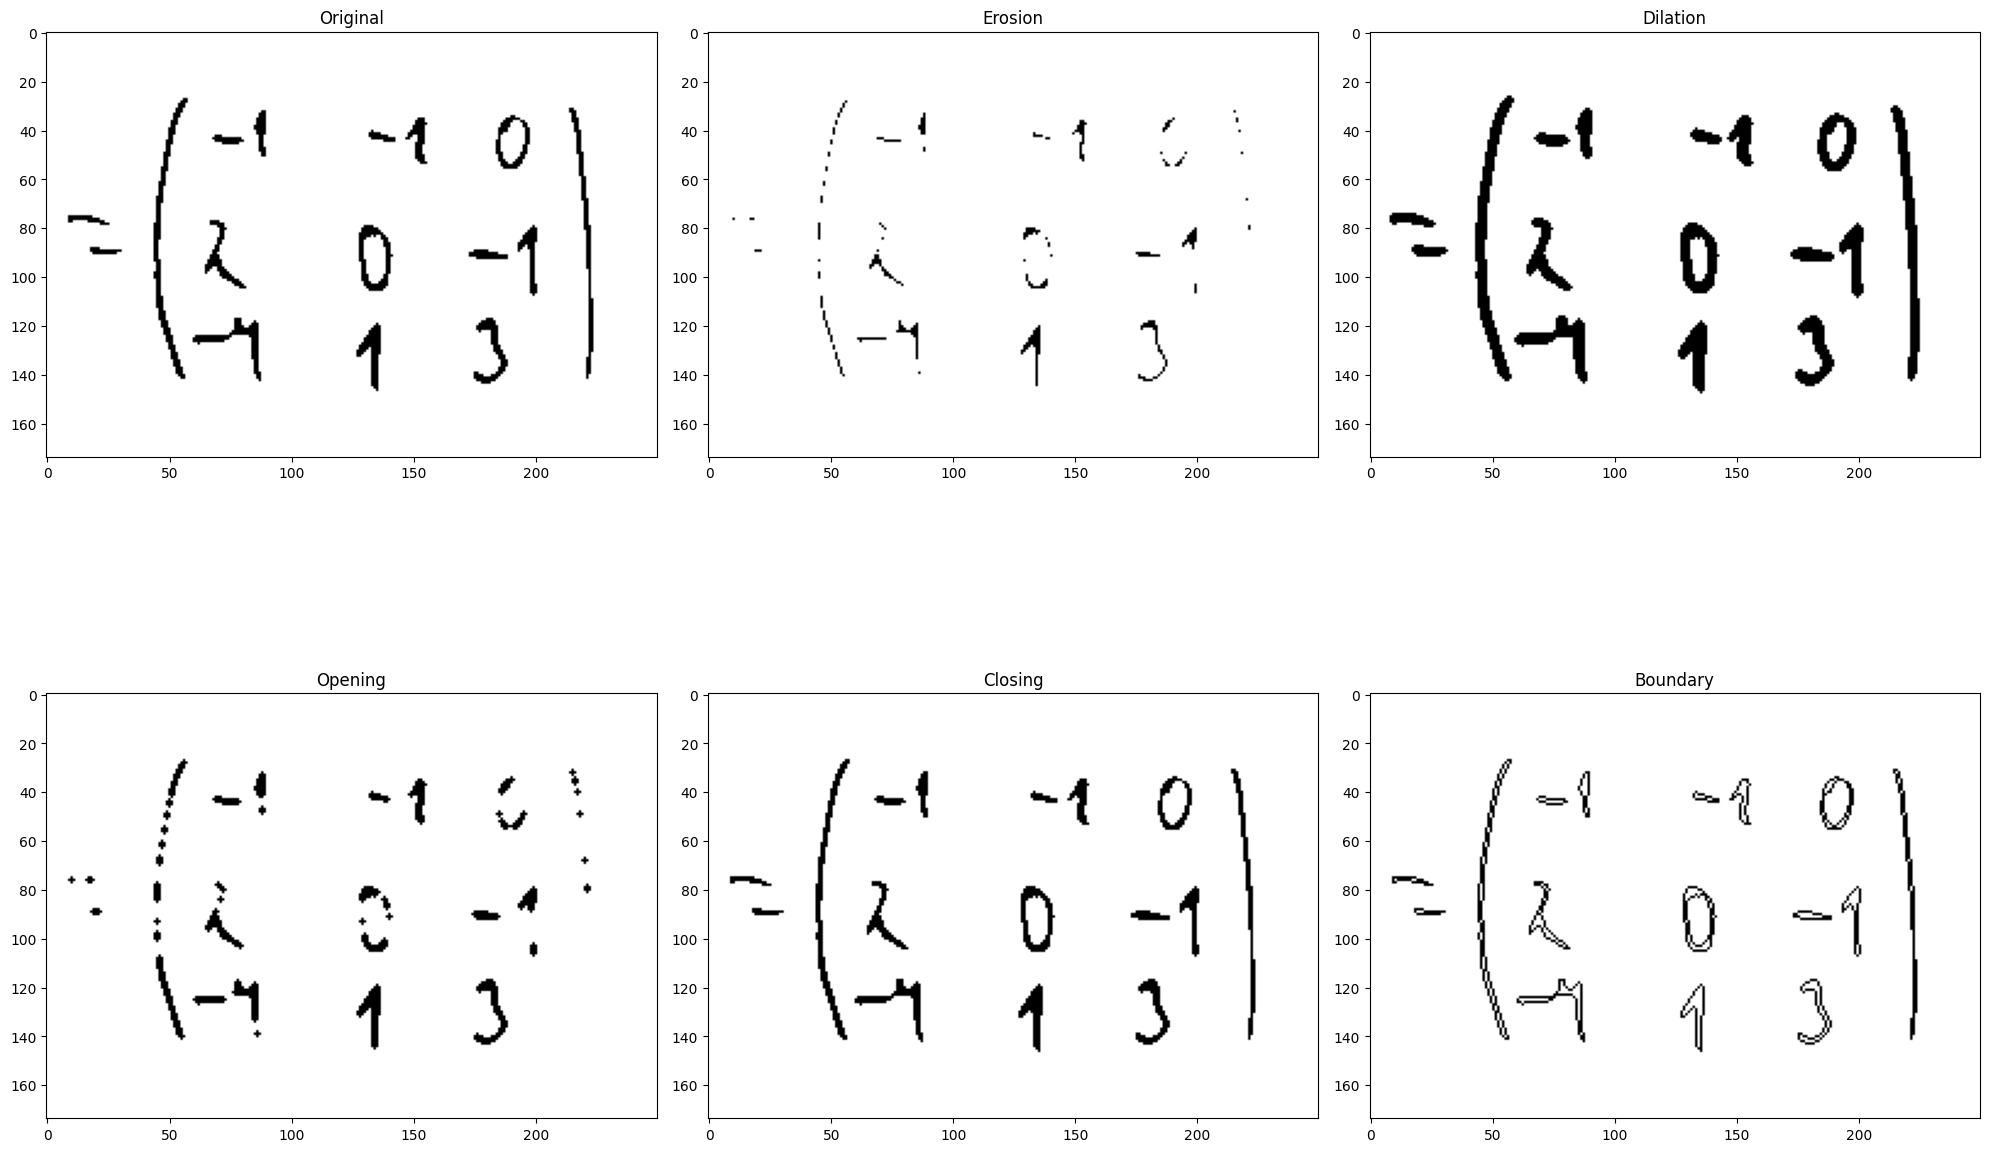

In [194]:
plt.figure(figsize=(20, 15))

plt.subplot(2, 3, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(2, 3, 2)
plt.title("Erosion")
plt.imshow(er, cmap='gray')

plt.subplot(2, 3, 3)
plt.title("Dilation")
plt.imshow(dil, cmap='gray')

plt.subplot(2, 3, 4)
plt.title("Opening")
plt.imshow(op, cmap='gray')

plt.subplot(2, 3, 5)
plt.title("Closing")
plt.imshow(clo, cmap='gray')

plt.subplot(2, 3, 6)
plt.title("Boundary")
plt.imshow(bound, cmap='gray')

plt.tight_layout()
plt.show()